# S4/S5 · AndinaLog · Notebook 3 · Interpretación de seguimiento de inventario

Este notebook **solo lee** la capa utilizable de `andinalog_inventory_tracking_silver.csv` (o el dataset tratado sin filas en cuarentena generado por el notebook 2). Calcula estadísticas descriptivas de permanencia en almacén, mermas físicas y costos asociados, muestra gráficos de distribución y series temporales, y redacta una síntesis automática con las cifras de la ejecución. No corrige datos, no modifica la capa Silver y no exporta archivos.

Las cifras de merma y días de permanencia se interpretan como observaciones físicas del dataset. Sin conocer las políticas de rotación FEFO/FIFO por producto o los límites tolerables de merma por centro, el notebook no redefine una merma como anomalía ni juzga la eficiencia de la operación. Las diferencias observadas describen la operación; no prueban causas.

## 1 · Carga local o desde Drive

En local, ejecuta el notebook desde cualquier carpeta del repositorio. En Colab, ajusta `RUTA_PROYECTO_DRIVE` a la carpeta que contiene `S4/`. Las fechas se agrupan tal como están registradas en el CSV; no se les asigna una zona horaria que no esté documentada.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ENTORNO = "auto"  # "auto", "local" o "drive"
RUTA_PROYECTO_DRIVE = "/content/drive/MyDrive/GIAD"
NOMBRE_SILVER = "andinalog_inventory_tracking_silver.csv"
COLUMNAS_SILVER = [
    "movimiento_id", "lote_id", "producto_id", "centro_distribucion",
    "fecha_ingreso", "fecha_salida", "fecha_vencimiento",
    "cantidad_ingreso", "cantidad_salida", "cantidad_merma",
    "dias_en_almacen", "costo_unitario_bob"
]

def encontrar_raiz_local():
    for carpeta in [Path.cwd(), *Path.cwd().parents]:
        salidas = carpeta / "S4" / "andinalog_inventory_tracking" / "notebook2" / "salidas"
        if (salidas / NOMBRE_SILVER).is_file() or (salidas / "andinalog_inventory_tracking_tratado.csv").is_file():
            return carpeta
    raise FileNotFoundError("No se encontró Silver. Ejecuta dentro del proyecto después de los notebooks 1 y 2.")

def obtener_ruta_silver():
    entorno = ENTORNO
    if entorno == "auto":
        entorno = "drive" if "google.colab" in sys.modules else "local"
    if entorno == "drive":
        from google.colab import drive
        drive.mount("/content/drive")
        raiz = Path(RUTA_PROYECTO_DRIVE)
    elif entorno == "local":
        raiz = encontrar_raiz_local()
    else:
        raise ValueError("ENTORNO debe ser 'auto', 'local' o 'drive'")

    salidas = raiz / "S4" / "andinalog_inventory_tracking" / "notebook2" / "salidas"
    ruta_silver = salidas / NOMBRE_SILVER
    ruta_tratado = salidas / "andinalog_inventory_tracking_tratado.csv"

    if ruta_silver.is_file():
        return ruta_silver
    elif ruta_tratado.is_file():
        return ruta_tratado
    else:
        raise FileNotFoundError(f"No se encontró archivo utilizable en: {salidas}")

RUTA_SILVER = obtener_ruta_silver()
print("Silver localizado:", RUTA_SILVER)

Mounted at /content/drive
Silver localizado: /content/drive/MyDrive/GIAD/S4/andinalog_inventory_tracking/notebook2/salidas/andinalog_inventory_tracking_tratado.csv


## 2 · Contrato de entrada

Esta comprobación valida que el archivo no contenga valores vacíos en las columnas obligatorias, formatos de fecha inválidos, mermas negativas ni duplicados de clave primaria. Si el archivo de entrada proviene del dataset tratado completo, filtra automáticamente las filas en cuarentena final para conservar únicamente las observaciones utilizables.

In [2]:
df_silver_raw = pd.read_csv(RUTA_SILVER, dtype="string", encoding="utf-8-sig", keep_default_na=False)

# Si se leyó el dataset tratado del notebook 2, extraer únicamente las filas sin cuarentena final
if "en_cuarentena_final" in df_silver_raw.columns:
    df_silver_raw = df_silver_raw.loc[df_silver_raw["en_cuarentena_final"].str.lower().ne("true")].copy()
    if "fecha_ingreso_preparada" in df_silver_raw.columns:
        df_silver_raw["fecha_ingreso"] = df_silver_raw["fecha_ingreso_preparada"]
    if "cantidad_ingreso_preparada" in df_silver_raw.columns:
        df_silver_raw["cantidad_ingreso"] = df_silver_raw["cantidad_ingreso_preparada"]
    df_silver_raw = df_silver_raw[COLUMNAS_SILVER].copy()

if list(df_silver_raw.columns) != COLUMNAS_SILVER:
    raise ValueError(f"Esquema Silver inesperado: {list(df_silver_raw.columns)}")
if df_silver_raw.empty:
    raise ValueError("Silver está vacío")
if df_silver_raw[["movimiento_id", "lote_id", "producto_id", "centro_distribucion", "fecha_ingreso", "cantidad_ingreso", "cantidad_salida", "cantidad_merma", "dias_en_almacen", "costo_unitario_bob"]].eq("").any().any():
    raise ValueError("Silver contiene valores vacíos en columnas obligatorias")

df = df_silver_raw.copy(deep=True)
df["fecha_ingreso"] = pd.to_datetime(df["fecha_ingreso"], format="%Y-%m-%d", errors="raise")
df["fecha_salida"] = pd.to_datetime(df["fecha_salida"], format="%Y-%m-%d", errors="coerce")
df["fecha_vencimiento"] = pd.to_datetime(df["fecha_vencimiento"], format="%Y-%m-%d", errors="raise")

for columna in ["cantidad_ingreso", "cantidad_salida", "cantidad_merma", "dias_en_almacen", "costo_unitario_bob"]:
    df[columna] = pd.to_numeric(df[columna], errors="raise")

if df[["cantidad_ingreso", "cantidad_salida", "cantidad_merma", "dias_en_almacen", "costo_unitario_bob"]].isna().any().any():
    raise ValueError("Silver contiene valores no numéricos")
if (df["cantidad_merma"] < 0).any():
    raise ValueError("Silver contiene mermas físicas negativas. Reejecuta los notebooks 1 y 2 corregidos.")
if df.duplicated(["movimiento_id"]).any():
    raise ValueError("Silver contiene movimientos duplicados")

# Métricas calculadas para análisis de negocio
df["perdida_merma_bob"] = (df["cantidad_merma"] * df["costo_unitario_bob"]).round(2)
df["pct_merma"] = ((df["cantidad_merma"] / df["cantidad_ingreso"]) * 100).round(2)

print(f"Lotes utilizables: {len(df):,}")
print(f"Productos cubiertos: {df['producto_id'].nunique():,}; Centros de distribución: {df['centro_distribucion'].nunique():,}")
print("Periodo de ingresos:", df["fecha_ingreso"].min().strftime("%Y-%m-%d"), "a", df["fecha_ingreso"].max().strftime("%Y-%m-%d"))

Lotes utilizables: 5,971
Productos cubiertos: 84; Centros de distribución: 5
Periodo de ingresos: 2026-05-01 a 2026-08-28


## 3 · Resumen general de mediciones y mermas

Se calculan estadísticas descriptivas de las magnitudes de inventario: cantidades movilizadas, mermas físicas, días de permanencia en almacén y pérdida económica en bolivianos (Bs).


In [3]:
columnas_num = ["cantidad_ingreso", "cantidad_salida", "cantidad_merma", "dias_en_almacen", "costo_unitario_bob", "perdida_merma_bob", "pct_merma"]
mediciones = df[columnas_num].describe(percentiles=[0.25, 0.5, 0.75]).T
mediciones = mediciones.rename(columns={"count": "registros", "mean": "media", "std": "desv_est", "min": "minimo", "25%": "p25", "50%": "mediana", "75%": "p75", "max": "maximo"})
mediciones = mediciones[["registros", "media", "mediana", "desv_est", "minimo", "p25", "p75", "maximo"]]
display(mediciones.round(2))

resumen_mermas = pd.DataFrame([
    {"indicador": "Lotes con merma física (>0)", "lotes": int((df["cantidad_merma"] > 0).sum()), "total_lotes": len(df), "porcentaje": 100 * (df["cantidad_merma"] > 0).mean()},
    {"indicador": "Lotes con merma superior al 5%", "lotes": int((df["pct_merma"] > 5.0).sum()), "total_lotes": len(df), "porcentaje": 100 * (df["pct_merma"] > 5.0).mean()},
])
display(resumen_mermas.round(2))


,registros,media,mediana,desv_est,minimo,p25,p75,maximo
cantidad_ingreso,5971.0,518.75,517.0,274.34,50.0,282.5,752.0,999.0
cantidad_salida,5971.0,507.76,505.0,269.93,42.0,276.0,739.0,992.0
cantidad_merma,5971.0,7.99,5.0,8.28,0.0,3.0,10.0,85.0
dias_en_almacen,5971.0,17.47,16.0,9.53,1.0,11.0,23.0,75.0
costo_unitario_bob,5971.0,45.4,44.33,22.8,12.64,23.87,64.93,84.36
perdida_merma_bob,5971.0,338.12,219.36,391.73,0.0,89.72,429.3,4437.18
pct_merma,5971.0,1.56,1.03,1.31,0.0,0.65,2.53,22.0


,indicador,lotes,total_lotes,porcentaje
0,Lotes con merma física (>0),5890,5971,98.64
1,Lotes con merma superior al 5%,127,5971,2.13


## 4 · Comportamiento por centro de distribución

Se evalúa la concentración de inventario, días promedio de almacén y costo económico acumulado por merma en cada uno de los centros de distribución de la red logística.

In [4]:
tabla_centros = df.groupby("centro_distribucion", sort=True).agg(
    lotes_atendidos=("lote_id", "count"),
    unidades_ingresadas=("cantidad_ingreso", "sum"),
    unidades_merma=("cantidad_merma", "sum"),
    perdida_total_bob=("perdida_merma_bob", "sum"),
    dias_prom_almacen=("dias_en_almacen", "mean"),
    pct_merma_prom=("pct_merma", "mean"),
)
tabla_centros["pct_merma_global"] = 100 * (tabla_centros["unidades_merma"] / tabla_centros["unidades_ingresadas"])
display(tabla_centros.round(2))

print("Centro con mayor pérdida acumulada por merma:", tabla_centros["perdida_total_bob"].idxmax(), f"({tabla_centros['perdida_total_bob'].max():,.2f} Bs)")
print("Centro con mayor permanencia promedio (días):", tabla_centros["dias_prom_almacen"].idxmax(), f"({tabla_centros['dias_prom_almacen'].max():.2f} días)")

,lotes_atendidos,unidades_ingresadas,unidades_merma,perdida_total_bob,dias_prom_almacen,pct_merma_prom,pct_merma_global
centro_distribucion,,,,,,,
Cochabamba,1196,614328,9429,393685.52,17.26,1.55,1.53
La Paz,1190,619881,9503,404126.84,17.49,1.54,1.53
Oruro,1246,642976,10142,428443.05,17.13,1.57,1.58
Santa Cruz,1141,593806,8896,392394.28,17.55,1.54,1.5
Tarija,1198,626459,9762,400250.19,17.92,1.58,1.56


Centro con mayor pérdida acumulada por merma: Oruro (428,443.05 Bs)
Centro con mayor permanencia promedio (días): Tarija (17.92 días)


## 5 · Evolución temporal de ingresos y mermas

Se calcula el comportamiento de ingresos diarios de inventario para detectar picos operativos o variaciones en la tasa de merma a lo largo del tiempo.

In [5]:
df["fecha_registrada"] = df["fecha_ingreso"].dt.date
tabla_diaria = df.groupby("fecha_registrada", sort=True).agg(
    lotes=("lote_id", "count"),
    unidades_ingreso=("cantidad_ingreso", "sum"),
    unidades_merma=("cantidad_merma", "sum"),
    dias_almacen_mediana=("dias_en_almacen", "median"),
    perdida_bob=("perdida_merma_bob", "sum"),
)
tabla_diaria["pct_merma_diaria"] = 100 * tabla_diaria["unidades_merma"] / tabla_diaria["unidades_ingreso"]
assert tabla_diaria["lotes"].sum() == len(df)
display(tabla_diaria.head(10).round(2))

,lotes,unidades_ingreso,unidades_merma,dias_almacen_mediana,perdida_bob,pct_merma_diaria
fecha_registrada,,,,,,
2026-05-01,47,23584,348,14.0,16132.81,1.48
2026-05-02,55,30529,436,18.0,15135.74,1.43
2026-05-03,60,30536,479,15.0,21376.09,1.57
2026-05-04,45,21794,329,17.0,14545.91,1.51
2026-05-05,53,25623,358,14.0,14068.08,1.4
2026-05-06,55,30983,472,15.0,20193.26,1.52
2026-05-07,49,31213,476,13.0,17980.76,1.53
2026-05-08,49,25120,334,19.0,15776.04,1.33
2026-05-09,61,28085,465,17.0,21565.55,1.66


## 6 · Gráficos de diagnóstico descriptivo

Las distribuciones muestran la permanencia en almacén y la pérdida económica de las mermas; la serie temporal ilustra el volumen diario y el porcentaje de merma registrado.


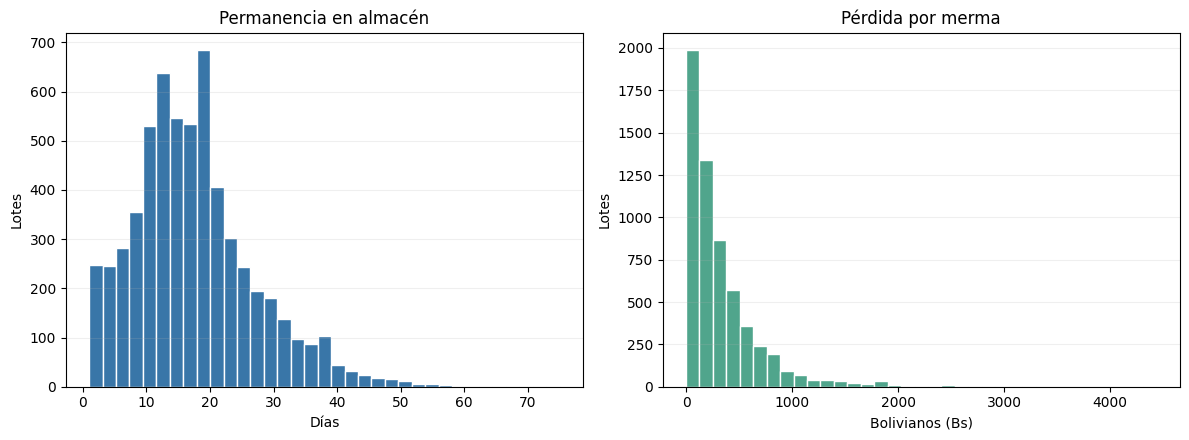

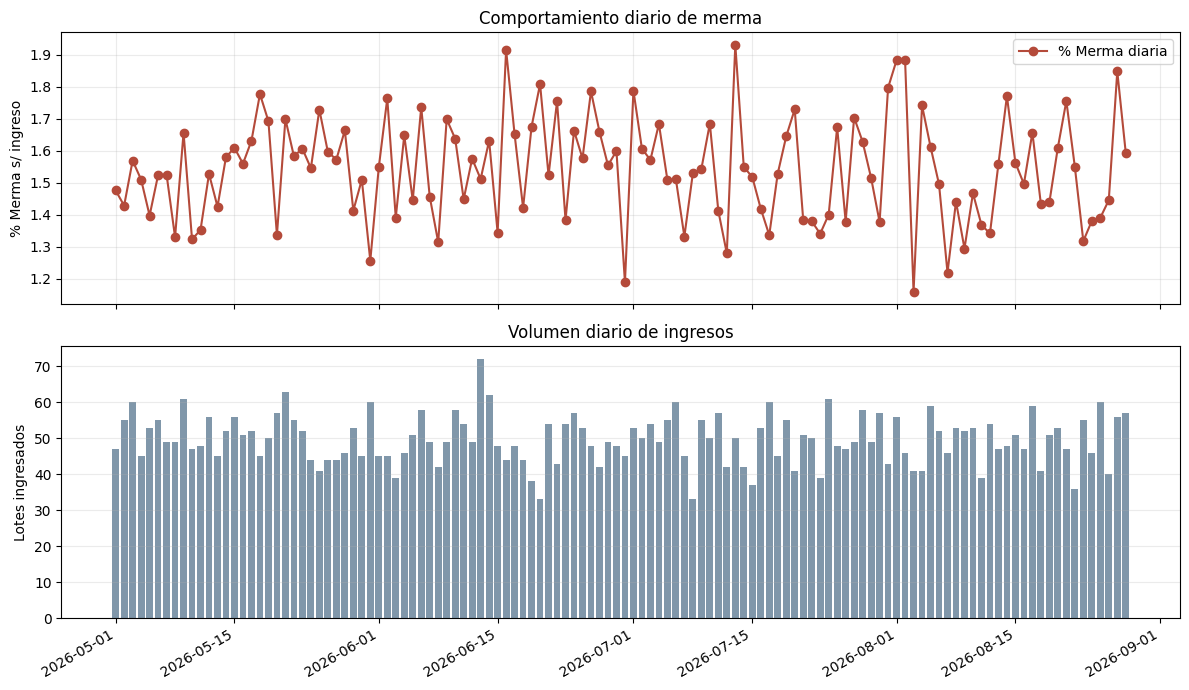

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df["dias_en_almacen"], bins=35, color="#3976A8", edgecolor="white")
axes[0].set(title="Permanencia en almacén", xlabel="Días", ylabel="Lotes")

axes[1].hist(df["perdida_merma_bob"], bins=35, color="#50A58C", edgecolor="white")
axes[1].set(title="Pérdida por merma", xlabel="Bolivianos (Bs)", ylabel="Lotes")

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
dias = pd.to_datetime(tabla_diaria.index)
axes[0].plot(dias, tabla_diaria["pct_merma_diaria"], marker="o", label="% Merma diaria", color="#B44A3A")
axes[0].set_ylabel("% Merma s/ ingreso")
axes[0].set_title("Comportamiento diario de merma")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].bar(dias, tabla_diaria["lotes"], color="#8097AA", width=0.8)
axes[1].set_ylabel("Lotes ingresados")
axes[1].set_title("Volumen diario de ingresos")
axes[1].grid(axis="y", alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 7 · Relación entre permanencia y nivel de merma

Se evalúa si los lotes con permanencia prolongada en almacén concentran una mayor incidencia de mermas físicas.

In [7]:
df["rango_almacen"] = pd.cut(
    df["dias_en_almacen"],
    bins=[0, 7, 15, 30, 100],
    labels=["1 a 7 días", "8 a 15 días", "16 a 30 días", "Más de 30 días"]
)

cruce_permanencia = df.groupby("rango_almacen", observed=False).agg(
    total_lotes=("lote_id", "count"),
    lotes_con_merma=("cantidad_merma", lambda s: (s > 0).sum()),
    merma_promedio=("cantidad_merma", "mean"),
    perdida_promedio_bob=("perdida_merma_bob", "mean"),
)
cruce_permanencia["pct_lotes_afectados"] = 100 * cruce_permanencia["lotes_con_merma"] / cruce_permanencia["total_lotes"]
display(cruce_permanencia.round(2))
assert cruce_permanencia["total_lotes"].sum() == len(df)

,total_lotes,lotes_con_merma,merma_promedio,perdida_promedio_bob,pct_lotes_afectados
rango_almacen,,,,,
1 a 7 días,775,775,11.28,446.56,100.0
8 a 15 días,2067,2033,7.68,325.4,98.36
16 a 30 días,2544,2503,6.8,293.51,98.39
Más de 30 días,585,579,9.95,433.38,98.97


## 8 · Síntesis descriptiva automática

El resumen ejecutivo se redacta dinámicamente con los datos de esta ejecución para servir de insumo al Informe Técnico y la Matriz de Trazabilidad.


In [8]:
def redactar_sintesis(datos, centros, diaria, permanencia):
    n = len(datos)
    c = len(centros)
    merma_tot = int(datos["cantidad_merma"].sum())
    perdida_tot = datos["perdida_merma_bob"].sum()
    centro_max = centros["perdida_total_bob"].idxmax()
    dia_max = diaria["pct_merma_diaria"].idxmax()

    lineas = [
        f"ALCANCE: {n:,} lotes utilizables distribuidos en {c} centros de distribución, registrados en {len(diaria)} fechas de ingreso. "
        "Las filas en cuarentena no forman parte de estos cálculos.",
        f"MEDICIONES CLAVE: permanencia mediana de {datos['dias_en_almacen'].median():.1f} días (media {datos['dias_en_almacen'].mean():.2f} días) "
        f"y costo unitario promedio de {datos['costo_unitario_bob'].mean():.2f} Bs.",
        f"MERMAS Y PÉRDIDAS: se registraron {merma_tot:,} unidades de merma física acumulada, representando una pérdida económica total de {perdida_tot:,.2f} Bs "
        f"(promedio {datos['perdida_merma_bob'].mean():.2f} Bs por lote).",
        f"CENTRO CRÍTICO: {centro_max} concentra la mayor pérdida económica acumulada por merma con {centros.loc[centro_max, 'perdida_total_bob']:,.2f} Bs "
        f"y un promedio de permanencia de {centros.loc[centro_max, 'dias_prom_almacen']:.2f} días.",
        f"FECHA A REVISAR: {dia_max} registró la mayor tasa diaria observada de merma ({diaria.loc[dia_max, 'pct_merma_diaria']:.2f} % "
        f"sobre {int(diaria.loc[dia_max, 'unidades_ingreso'])} unidades ingresadas). Debe revisarse la naturaleza de los lotes antes de inferir causas.",
        "LÍMITE: las cifras descriptivas no prueban fallas operativas individuales ni consideran los requisitos térmicos específicos de cada producto.",
    ]
    return "\n\n".join(lineas)

sintesis_descriptiva = redactar_sintesis(df, tabla_centros, tabla_diaria, cruce_permanencia)
print(sintesis_descriptiva)

ALCANCE: 5,971 lotes utilizables distribuidos en 5 centros de distribución, registrados en 120 fechas de ingreso. Las filas en cuarentena no forman parte de estos cálculos.

MEDICIONES CLAVE: permanencia mediana de 16.0 días (media 17.47 días) y costo unitario promedio de 45.40 Bs.

MERMAS Y PÉRDIDAS: se registraron 47,732 unidades de merma física acumulada, representando una pérdida económica total de 2,018,899.88 Bs (promedio 338.12 Bs por lote).

CENTRO CRÍTICO: Oruro concentra la mayor pérdida económica acumulada por merma con 428,443.05 Bs y un promedio de permanencia de 17.13 días.

FECHA A REVISAR: 2026-07-13 registró la mayor tasa diaria observada de merma (1.93 % sobre 24393 unidades ingresadas). Debe revisarse la naturaleza de los lotes antes de inferir causas.

LÍMITE: las cifras descriptivas no prueban fallas operativas individuales ni consideran los requisitos térmicos específicos de cada producto.


## 9 · Guía de interpretación industrial

Al analizar los resultados para el Informe Técnico, enfócate en:
1. **Permanencia en almacén:** ¿Qué proporción de lotes supera los 15 o 30 días de rotación? Esta métrica es fundamental para el cruce de la Evidencia 2 con la fecha de vencimiento.
2. **Distribución de mermas:** ¿Las pérdidas se concentran en pocos lotes de alto valor unitario o en volúmenes pequeños dispersos en todos los centros?
3. **Equilibrio entre centros:** Las diferencias observadas entre Oruro, Cochabamba, Santa Cruz, La Paz y Tarija orientan las políticas de abastecimiento hacia el Módulo 4.

## 10 · Validaciones finales

Las sumas agregadas deben cuadrar exactamente con el total de filas de la capa preparada. El notebook no escribe ni modifica archivos.

In [9]:
assert len(df) == len(df_silver_raw)
assert "fecha_registrada" not in df_silver_raw.columns
assert tabla_diaria["lotes"].sum() == len(df)
assert tabla_centros["lotes_atendidos"].sum() == len(df)
assert cruce_permanencia["total_lotes"].sum() == len(df)
assert f"{len(df):,} lotes utilizables" in sintesis_descriptiva
print("Validaciones correctas. Silver no fue modificado.")

Validaciones correctas. Silver no fue modificado.
